In this tutorial, we will walk through how to create the template-based training images and train the model.

In [1]:
%cd ..

/home/qifan/L2G


### Create the template-based training images

In [2]:
!python tools/Compose_objects.py \
--objects-root data/Templates/RoboTools_all \
--backgrounds Backgrounds_2048 \
--out-root RoboTools_create \
--bbox-out-root RoboTools_create_bbox \
--start-object-id 1 \
--end-object-id 3

all_obj_ids: [1, 2, 3]
[Info] Backgrounds: 2000
[Info] Objects: 000001..000003
[Info] Scale: [1.2, 2.0]  Blur: p=0.4, r=[0.8,2.2]  Rot: p=0.5
[Info] Output root: /home/qifan/L2G/RoboTools_create
[Info] BBox Output root: /home/qifan/L2G/RoboTools_create_bbox
[Obj 000001] Wrote 200 pairs -> /home/qifan/L2G/RoboTools_create/rgb/000001 / /home/qifan/L2G/RoboTools_create/mask/000001 and /home/qifan/L2G/RoboTools_create_bbox/rgb/000001 / /home/qifan/L2G/RoboTools_create_bbox/mask/000001
[Obj 000002] Wrote 200 pairs -> /home/qifan/L2G/RoboTools_create/rgb/000002 / /home/qifan/L2G/RoboTools_create/mask/000002 and /home/qifan/L2G/RoboTools_create_bbox/rgb/000002 / /home/qifan/L2G/RoboTools_create_bbox/mask/000002
[Obj 000003] Wrote 200 pairs -> /home/qifan/L2G/RoboTools_create/rgb/000003 / /home/qifan/L2G/RoboTools_create/mask/000003 and /home/qifan/L2G/RoboTools_create_bbox/rgb/000003 / /home/qifan/L2G/RoboTools_create_bbox/mask/000003


### Show an example of template-based training images

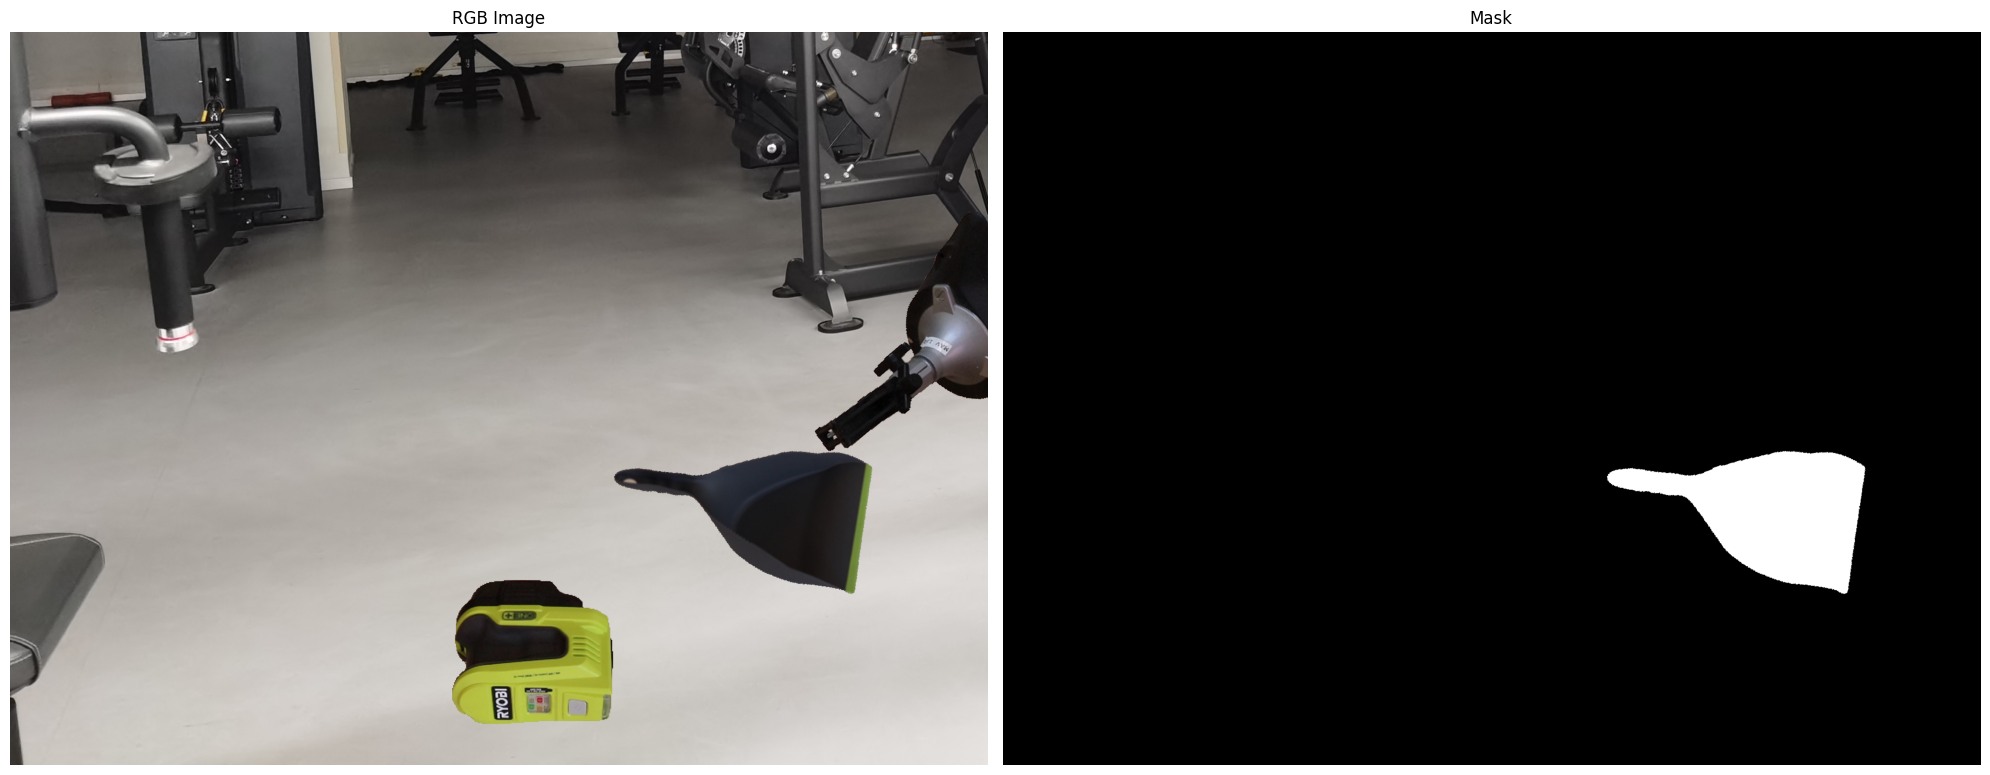

In [8]:
import matplotlib.pyplot as plt
import cv2

# Get RGB
rgb = cv2.imread("RoboTools_create/rgb/000001/000001.jpg")
rgb = cv2.cvtColor(rgb, cv2.COLOR_BGR2RGB)

# Get Mask
mask = cv2.imread("RoboTools_create/mask/000001/000001.png", cv2.IMREAD_GRAYSCALE)

# Show
plt.figure(figsize=(20,10))

plt.subplot(1, 2, 1)
plt.imshow(rgb)
plt.title("RGB Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap="gray")
plt.title("Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

### Train the Object_tokens

In [9]:
!python sam2_trainer.py \
  --data_root ./ \
  --training_data RoboTools_create \
  --object_id 000001 \
  --model_cfg configs/sam2.1/sam2.1_hiera_l.yaml \
  --checkpoint checkpoints/SAM/sam2.1_hiera_large.pt \
  --lr 5e-3


##############n_objects: 1
model.image_size: 1024
[Epoch 1/1] step=10 loss=0.2579
[Epoch 1/1] step=20 loss=0.1228
[Epoch 1/1] step=30 loss=0.1025
[Epoch 1/1] step=40 loss=0.0461
[Epoch 1/1] step=50 loss=1.3966
[Epoch 1/1] step=60 loss=0.0511
[Epoch 1/1] step=70 loss=0.0419
[Epoch 1/1] step=80 loss=0.0461
[Epoch 1/1] step=90 loss=0.0469
[Epoch 1/1] step=100 loss=0.0346
[Epoch 1/1] step=110 loss=0.0515
[Epoch 1/1] step=120 loss=0.1061
[Epoch 1/1] step=130 loss=0.0453
[Epoch 1/1] step=140 loss=0.4025
[Epoch 1/1] step=150 loss=0.3018
[Epoch 1/1] step=160 loss=0.1585
[Epoch 1/1] step=170 loss=0.0477
[Epoch 1/1] step=180 loss=0.0565
[Epoch 1/1] step=190 loss=0.0677
[Epoch 1/1] step=200 loss=0.0313
[Epoch 1/1] Loss=0.1417
✅ Saved tokens for 000001 (best loss 0.1417)
